In [1]:
import re
import random
from collections import Counter

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")


Device: cuda


# Word2Vec

Word2Vec is a method for learning dense vector representations (word embeddings) from word co-occurrence patterns in a text corpus. Main idea: words appearing in similar contexts should have similar vector representations.

Word2Vec includes two architectures: CBOW and Skip-Gram. In this implementation, we use Skip-Gram with Negative Sampling (SGNS). For each center word, the words that actually appear around it are treated as positive examples, while randomly sampled words are used as negative examples. The model learns to distinguish between these two types of pairs, gradually adjusting the word vectors so that words with similar contexts get similar representations.

## Loading dataset, preprocessing and tokenization

We load the WikiText-2 dataset and use the training split as our text corpus. Empty or very short entries are removed, keeping only texts longer than 100 characters. The remaining text is then preprocessed by converting it to lowercase, removing punctuation and special characters, and normalizing whitespace. Finally, the cleaned text is split into individual words, producing a list of tokens that will be used for training the Word2Vec model.

In [2]:
from datasets import load_dataset

dataset = load_dataset("Salesforce/wikitext", "wikitext-2-raw-v1", split="train")
dataset

Dataset({
    features: ['text'],
    num_rows: 36718
})

In [3]:
texts = [t for t in dataset['text'] if len(t.strip()) > 100]

print(f"Loaded {len(texts)} examples")
print(f"Example:\n {texts[300]}")

Loaded 15272 examples
Example:
  There are an estimated 27 @,@ 000 civil aircraft registered in the UK , 96 per cent of which are engaged in GA activities . In 2005 the GA fleet comprised 9 @,@ 000 fixed @-@ wing aircraft , 4 @,@ 100 microlights , 1 @,@ 300 helicopters , 1 @,@ 800 airships / balloons , 2 @,@ 500 gliders and some 7 @,@ 000 hang gliders . Estimates put the number of foreign @-@ registered GA aircraft based in the UK at 900 . 



In [4]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize(texts):
    tokens = []
    for t in texts:
        cleaned = clean_text(t)
        if cleaned:
            tokens.extend(cleaned.split())
    return tokens


In [5]:
tokens = tokenize(texts)
print(f"Total tokens: {len(tokens)}")
print(f"Most frequent tokens: {Counter(tokens).most_common(10)}")

Total tokens: 1719348
Most frequent tokens: [('the', 129887), ('of', 56385), ('and', 49709), ('in', 44667), ('to', 39325), ('a', 36283), ('was', 20956), ('on', 15039), ('as', 14904), ('s', 14322)]


## Building the vocabulary

**Vocab** class creates a vocabulary from text tokens. It filters out rare words using min_count and map each remaining word to a unique numerical ID.

It also calculates the relative frequency (freq) of each word in the corpus, which is then used in Mikolov’s subsampling formula from the Word2Vec paper. During subsampling, high-frequency words such as “the” or “and” have lower keep probabilities, making them more likely to be randomly discarded, while low-frequency words are more likely to be kept. This reduces repetitive training examples and prevents common words from dominating the learning process, allowing the model to learn better representations of less frequent words.

In [6]:
class Vocab:
    def __init__(self, tokens, min_count=5):
        self.counter = Counter(tokens)
        self.word_counts = {w:c for w,c in self.counter.items() if c>=min_count}

        self.words = list(self.word_counts.keys())
        self.word2idx = {w: i for i, w in enumerate(self.words)}
        self.idx2word = {i:w for w,i in self.word2idx.items()}

        self.size = len(self.words)
        total = sum(self.word_counts.values())
        self.freq = np.array(
            [self.word_counts[w]/total for w in self.words], dtype=np.float64
        )

    def encode(self, tokens):
        return [self.word2idx[t] for t in tokens if t in self.word2idx]

def subsample_tokens(token_ids, vocab, threshold=1e-4):
    keep_prob = {}
    for idx in set(token_ids):
        f = vocab.freq[idx]
        #mikolov formula: p(keep) = min(1, sqrt(t/f) + t/f)
        keep_prob[idx] = min(1.0, (np.sqrt(f / threshold) + 1) * (threshold / f))

    return [idx for idx in token_ids if random.random() < keep_prob[idx]]

In [7]:
vocab = Vocab(tokens, min_count=20)
print(f"Vocab size: {vocab.size}")

token_ids = vocab.encode(tokens)
print(f"Before subsampling: {len(token_ids)}")
token_ids = subsample_tokens(token_ids, vocab)
print(f"After subsampling: {len(token_ids)}")

Vocab size: 8059
Before subsampling: 1529944
After subsampling: 827428


## Skip-gram pairs and negative sampling

These functions prepare the training data for SGNS (Skip-Gram with Negative Sampling). `generate_skipgram_pairs` returns a list of (center, context) word index pairs generated using a randomly sized context window around each center word.
 Negative words are sampled from a frequency-adjusted distribution where word frequencies are raised to the power of 0.75, reducing the dominance of very frequent words while still sampling them more often than rare words.

In [8]:
def generate_skipgram_pairs(token_ids, window_size=5):
    pairs = []
    for i, center in enumerate(token_ids):
        window = random.randint(1, window_size)
        start = max(0, i - window)
        end = min(len(token_ids), i + window + 1)
        for j in range(start, end):
            if i != j:
                pairs.append((center, token_ids[j]))
    return pairs

def negative_sampling_distribution(vocab, power=0.75):
    #mikolov smoothed unigram distribution
    probs = vocab.freq ** power
    probs /= probs.sum()
    return probs

`SkipGramDataset` prepares training examples for SGNS and inherits from PyTorch's `Dataset` so the examples can be efficiently loaded using a `DataLoader`.

- `__init__()` - stores the training pairs and builds a negative sampling table for efficient sampling.
- `__len__()` - returns the total number of training examples.
- `_sample_negatives()` - samples a fixed number of negative words and ensures they are different from the positive context word.
- `__getitem__(idx)` - returns one training example: the center word, positive context word, and negative samples.

Instead of calculating the sampling probability every time, the table contains word indices repeated according to their sampling probabilities. Therefore, more frequent words appear more often in the table and are more likely to be sampled as negative examples.

In [ ]:
class SkipGramDataset(Dataset):
    def __init__(self, pairs, neg_dist, num_negatives = 5, neg_table_size =1000000):
        super().__init__()
        self.pairs = pairs
        self.num_negatives = num_negatives

        # table for sampling negative examples
        vocab_size = len(neg_dist)
        counts = np.round(neg_dist * neg_table_size).astype(np.int64)
        counts = np.maximum(counts, 1)
        self.neg_table = np.repeat(np.arange(vocab_size), counts)

    def __len__(self):
        return len(self.pairs)

    def _sample_negatives(self, positive_idx):
        neg_samples = np.random.choice(self.neg_table, size=self.num_negatives)
        while positive_idx in neg_samples:
            neg_samples = np.random.choice(self.neg_table, size=self.num_negatives)
        return neg_samples

    def __getitem__(self, idx):
        center, context = self.pairs[idx]
        negatives = self._sample_negatives(context)
        return (
            torch.tensor(center, dtype=torch.long),
            torch.tensor(context, dtype=torch.long),
            torch.tensor(negatives, dtype=torch.long)
        )


In [10]:
pairs = generate_skipgram_pairs(token_ids, window_size=3)
print(f"Generated {len(pairs)} (center, context) pairs.")

neg_dist = negative_sampling_distribution(vocab)

NUM_NEGATIVES = 5
BATCH_SIZE = 64

dataset = SkipGramDataset(pairs,neg_dist,num_negatives=NUM_NEGATIVES)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

c, ctx, neg = next(iter(dataloader))
print("center batch shape:", c.shape)
print("context batch shape:", ctx.shape)
print("negatives batch shape:", neg.shape)


Generated 3308123 (center, context) pairs.
center batch shape: torch.Size([64])
context batch shape: torch.Size([64])
negatives batch shape: torch.Size([64, 5])


## Model - SGNS

Skip-Gram is actually a shallow, two-layer neural network. It turns words into numerical vectors by learning to predict the surrounding context words from a given target word. The prediction task itself is not the end goal; what we actually care about are the learned weights between the input and hidden layer, which become the word embeddings, while the prediction (output) layer is discarded after training.

The model has two embedding matrices: in_embed (center word vectors - the final embeddings we keep) and out_embed (context word vectors - used only during training, discarded afterward).

Instead of an expensive softmax over the whole vocabulary, it uses negative sampling: it computes the dot product between the center word and the positive context word (we want a high score), and the dot product between the center word and several negative (random) words (we want a low score). The total loss is the negative sum of these log-probabilities, and minimizing it teaches the network to distinguish real contexts from random words.

Loss function:
$$ L = -\log \sigma(v_c \cdot u_{ctx}) - \sum_{k=1}^{K} \log \sigma(-v_c \cdot u_{neg_k}) $$


In [11]:
class SkipGramNegSampling(nn.Module):
    def __init__(self, vocab_size: int, embed_dim: int=100):
        super().__init__()
        self.in_embed = nn.Embedding(vocab_size, embed_dim)
        self.out_embed = nn.Embedding(vocab_size, embed_dim)

        # weights init similar to original w2v
        nn.init.uniform_(self.in_embed.weight, -0.5 / embed_dim, 0.5 / embed_dim)
        nn.init.constant_(self.out_embed.weight, 0)

    def forward(self, center, context, negtaives):

        v_center = self.in_embed(center) # (batch, dim)
        u_context = self.out_embed(context) # (batch, dim)
        u_negatives = self.out_embed(negtaives) # (batch, K, dim)

        pos_score = torch.sum(v_center * u_context, dim=1) #(batch,)
        pos_loss = F.logsigmoid(pos_score) #(batch,)

        neg_score = torch.bmm(u_negatives, v_center.unsqueeze(2)).squeeze(2) # (batch, K)
        neg_loss = F.logsigmoid(-neg_score).sum(dim=1) #(batch,)

        loss = -(pos_loss+neg_loss).mean()
        return loss


## Training

We will use standard Pytorch loop for training:  

**forward -> loss -> backward -> optimizer step**

In [12]:
EMBED_DIM = 64
EPOCHS = 12
LR = 0.003

model = SkipGramNegSampling(vocab.size, embed_dim=EMBED_DIM).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LR)

for epoch in range(EPOCHS):
    total_loss = 0

    for center, context, negatives in dataloader:
        center = center.to(device)
        context = context.to(device)
        negatives = negatives.to(device)

        optimizer.zero_grad()
        loss = model(center, context, negatives)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    print(f"Epoch {epoch}/{EPOCHS} | loss = {avg_loss:.4f}")


Epoch 0/12 | loss = 2.5560
Epoch 1/12 | loss = 2.4761
Epoch 2/12 | loss = 2.4651
Epoch 3/12 | loss = 2.4610
Epoch 4/12 | loss = 2.4588
Epoch 5/12 | loss = 2.4576
Epoch 6/12 | loss = 2.4574
Epoch 7/12 | loss = 2.4566
Epoch 8/12 | loss = 2.4571
Epoch 9/12 | loss = 2.4569
Epoch 10/12 | loss = 2.4572
Epoch 11/12 | loss = 2.4565


The loss dropped sharply during the first few epochs and then stabilized around ~2.457 from epoch 6 onward, with only negligible fluctuations. This convergence pattern suggests the model may have learned meaningful word representations, though loss alone doesn't confirm this - we verify it next using cosine similarity.

In [13]:
import pickle

data_to_save = {
    "embeddings": model.in_embed.weight.data.cpu().numpy(),
    "word2idx": vocab.word2idx,
    "idx2word": vocab.idx2word,
}

with open("word2vec_embeddings.pkl", "wb") as f:
    pickle.dump(data_to_save, f)

## Finding similar words

Cosine similarity measures how similar two word vectors are by comparing the direction they point, rather than their length. The closer the value is to 1, the more similar the words are in meaning.

It is used to evaluate the quality of the learned embeddings by checking whether semantically related words are placed close together in the embedding space.

In [38]:
def most_similar(model, vocab, word, topn=5):
    if word not in vocab.word2idx:
        print(f"Word '{word}' is not part of the vocabulary!")
        return []

    embeddings = model.in_embed.weight.detach() # (vocab_size, dim)
    idx = vocab.word2idx[word]
    vec = embeddings[idx].unsqueeze(0) # (1, dim)

    sims = F.cosine_similarity(vec, embeddings) # (vocab_size,)
    top = torch.topk(sims, topn + 1)

    results = []
    for score, i in zip(top.values, top.indices):
        if i.item() == idx:
            continue
        results.append((vocab.idx2word[i.item()], score.item()))
        if len(results) >= topn:
            break
    return results

In [56]:
test_words = ["number", "earth", "tennis", "war"]

for word in test_words:
    print(f"\n{word}:")
    for similar, score in most_similar(model, vocab, word, topn=5):
        print(f"  {similar} {score:.3f}")


number:
  top 0.660
  numbers 0.562
  list 0.560
  singles 0.548
  100 0.505

earth:
  sun 0.615
  venus 0.600
  atmosphere 0.575
  orbital 0.549
  spacecraft 0.536

tennis:
  finals 0.545
  played 0.530
  fantasy 0.504
  tournaments 0.500
  federer 0.498

war:
  civil 0.579
  ii 0.535
  military 0.518
  outbreak 0.514
  army 0.495


These results suggest that the model learned meaningful relationships between words. For example, earth is associated with sun, venus, and atmosphere, while war is linked to civil, military, and army. Some similarities also reflect the context of the training corpus rather than only word meaning.


## Visualizing word embeddings with t-Sne

We take the learned embedding vectors for the 400 most frequent words and reduce them to 2D using t-SNE, then plot them as a scatter plot.
This lets us visually see which words end up close together in the embedding space (semantically/geometrically similar).

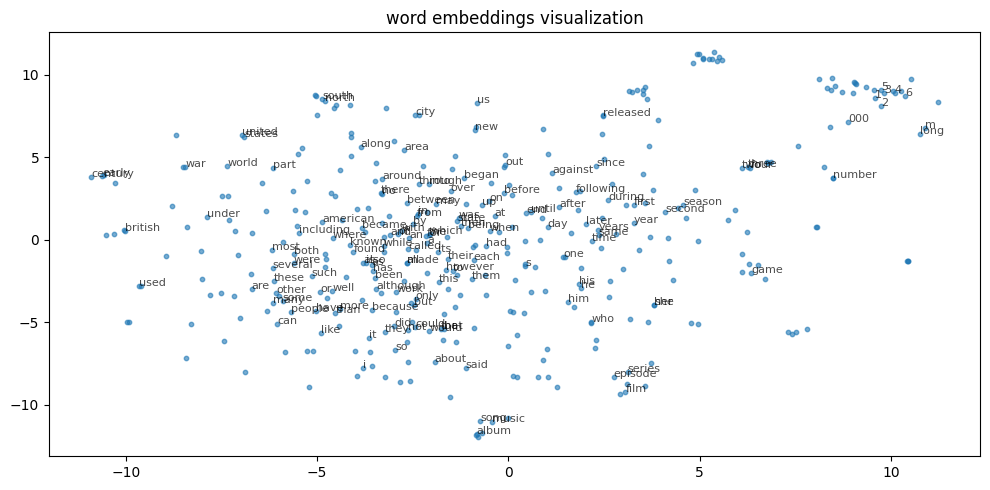

In [76]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

embeddings = model.in_embed.weight.detach().cpu().numpy()  # (vocab_size, EMBED_DIM)

N = 400
top_idx = np.argsort(-vocab.freq)[:N]
X = embeddings[top_idx]
words = [vocab.idx2word[i] for i in top_idx]

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init='pca',
    learning_rate='auto',
    random_state=42
)
X_2d = tsne.fit_transform(X)

plt.figure(figsize=(10, 5))
plt.scatter(X_2d[:, 0], X_2d[:, 1], s=10, alpha=0.6)

# annotate only a subset of words to avoid clutter
for i, word in enumerate(words[:150]):
    plt.annotate(word, (X_2d[i, 0], X_2d[i, 1]), fontsize=8, alpha=0.7)

plt.title("word embeddings visualization")
plt.tight_layout()
plt.show()

This suggests that the trained embeddings capture some meaningful relationships between words, with related words such as film, episode, series, music, and album appearing relatively close to each other. However, many common words remain densely distributed around the center, as they occur in a wide range of contexts.